<a href="https://colab.research.google.com/github/jyothisasidharan/ML_AI_Projects/blob/main/Mask_and_social_distancing_detection_using_VGG19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
lalitharajesh_haarcascades_path = kagglehub.dataset_download('lalitharajesh/haarcascades')
andrewmvd_face_mask_detection_path = kagglehub.dataset_download('andrewmvd/face-mask-detection')
ashishjangra27_face_mask_12k_images_dataset_path = kagglehub.dataset_download('ashishjangra27/face-mask-12k-images-dataset')

print('Data source import complete.')


100%|██████████| 1.45M/1.45M [00:00<00:00, 2.63MB/s]

Extracting files...


100%|██████████| 398M/398M [00:10<00:00, 38.8MB/s]

Extracting files...


Using Colab cache for faster access to the 'face-mask-12k-images-dataset' dataset.
Data source import complete.


# Mask and Social distancing Detection

![d8ce0480-9ac0-11ea-8062-809a1b8bfab6.png](attachment:d8ce0480-9ac0-11ea-8062-809a1b8bfab6.png)

**Social distancing**, also called **“physical distancing,”** means keeping a safe space between yourself and other people who are not from your household.

To practice social or physical distancing, stay at least 6 feet (about 2 arm lengths) from other people who are not from your household in both indoor and outdoor spaces.

**Objective** is to build a Deep Learning model which can identify if the person is wearing a mask or not, also detecting if people vilating social distancing norms.

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2
from scipy.spatial import distance
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask/Augmented_850_3888270.png
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask/Augmented_348_5679704.png
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask/Augmented_684_3026577.png
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask/Augmented_640_6283500.png
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask/Augmented_290_2810702.png
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask/Augmented_272_1257404.png
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask/Augmented_680_2431803.png
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask/Augmented_79_948721.png
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask/1231.png
/kaggle/input/face-mask-12k-images-dataset/Face Ma

### Using haar cascade to detect faces

Object Detection using Haar feature-based cascade classifiers is an effective object detection method proposed by Paul Viola and Michael Jones in their paper, "Rapid Object Detection using a Boosted Cascade of Simple Features" in 2001. It is a machine learning based approach where a cascade function is trained from a lot of positive and negative images. It is then used to detect objects in other images. We'll be using a Haar Cascade Model trained to detect faces in order to obtain the bounding box coordinates of faces in an image.

In [3]:
#loading haarcascade_frontalface_default.xml
import os
cascade_path = os.path.join(lalitharajesh_haarcascades_path, 'haarcascade_frontalface_default.xml')
face_model = cv2.CascadeClassifier(cascade_path)

if face_model.empty():
    print(f"Error: Face cascade classifier could not be loaded from {cascade_path}.")
    print("Please ensure the path is correct and the XML file exists.")
else:
    print("Face cascade classifier loaded successfully.")


Face cascade classifier loaded successfully.


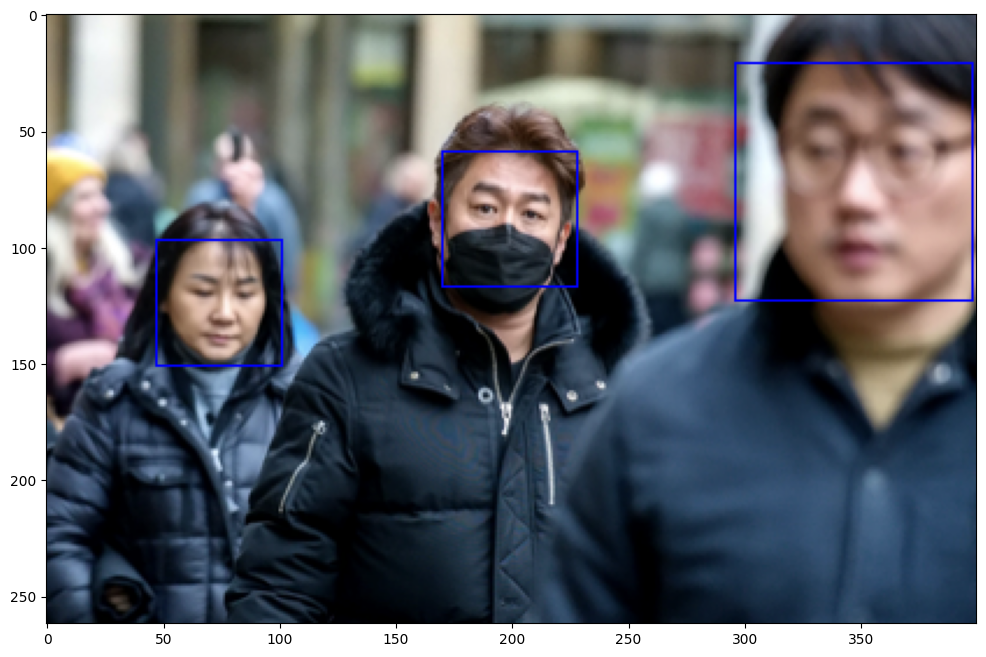

In [4]:
import matplotlib.pyplot as plt
import os # Ensure os is imported for os.path.join

#trying it out on a sample image
# Construct the correct image path using the variable from kagglehub.dataset_download
img_path = os.path.join(andrewmvd_face_mask_detection_path, 'images', 'maksssksksss244.png')
original_color_img = cv2.imread(img_path)

if original_color_img is None:
    print(f"Error: Could not load image from {img_path}. Please check the path and if the file exists.")
else:
    # Convert the loaded image (BGR by default) to grayscale for face detection
    gray_img = cv2.cvtColor(original_color_img, cv2.COLOR_BGR2GRAY)

    # Detect faces on the grayscale image
    faces = face_model.detectMultiScale(gray_img, scaleFactor=1.1, minNeighbors=4) #returns a list of (x,y,w,h) tuples

    # Prepare output image for plotting (convert original BGR to RGB for matplotlib)
    out_img = cv2.cvtColor(original_color_img, cv2.COLOR_BGR2RGB)

    #plotting
    for (x,y,w,h) in faces:
        cv2.rectangle(out_img,(x,y),(x+w,y+h),(0,0,255),1)
    plt.figure(figsize=(12,12))
    plt.imshow(out_img)

# Note: The `face_model` loading in cell `eFXjFFEJtSff` will likely also need to be updated
# to use `os.path.join(lalitharajesh_haarcascades_path, 'haarcascade_frontalface_default.xml')`

### Detecting social distancing violations

This can be done by iterating over the coordinates of faces and calculating the distance for each possible pair, if the distance for a particular pair is less than MIN_DISTANCE then the bounding boxes for those faces are colored red. MIN_DISTANCE must be manually initialized in such a way that it corresponds to the minimum allowable distance in real life (ex. 6ft in India).

In [5]:
MIN_DISTANCE = 130

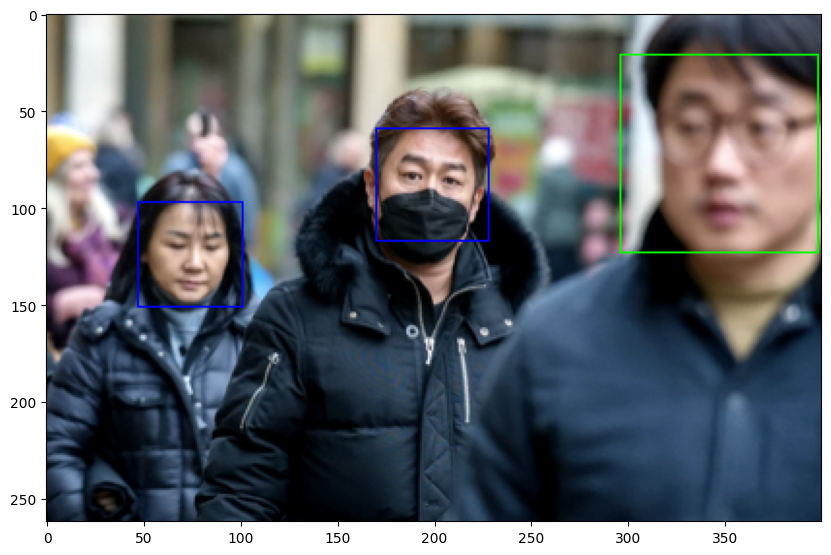

In [6]:
if len(faces)>=2:
    label = [0 for i in range(len(faces))]
    for i in range(len(faces)-1):
        for j in range(i+1, len(faces)):
            dist = distance.euclidean(faces[i][:2],faces[j][:2])
            if dist<MIN_DISTANCE:
                label[i] = 1
                label[j] = 1
    new_img = original_color_img.copy() # Use the original_color_img (BGR) and make a copy
    for i in range(len(faces)):
        (x,y,w,h) = faces[i]
        if label[i]==1:
            cv2.rectangle(new_img,(x,y),(x+w,y+h),(255,0,0),1)
        else:
            cv2.rectangle(new_img,(x,y),(x+w,y+h),(0,255,0),1)
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB)) # Convert to RGB for matplotlib display

else:
    print("No. of faces detected is less than 2")

#### Red box shows violation of social distancing.

### Using VGG19 for mask detection


In [7]:
from keras.applications.vgg19 import VGG19
from keras.applications.vgg19 import preprocess_input
from keras import Sequential
from keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
#Load train and test set
train_dir = '../input/face-mask-12k-images-dataset/Face Mask Dataset/Train'
test_dir = '../input/face-mask-12k-images-dataset/Face Mask Dataset/Test'
val_dir = '../input/face-mask-12k-images-dataset/Face Mask Dataset/Validation'

In [11]:
import os

# Data augmentation
# Correcting the paths using the kagglehub variable
base_dataset_path = os.path.join(ashishjangra27_face_mask_12k_images_dataset_path, 'Face Mask Dataset')
train_dir = os.path.join(base_dataset_path, 'Train')
test_dir = os.path.join(base_dataset_path, 'Test')
val_dir = os.path.join(base_dataset_path, 'Validation')

train_datagen = ImageDataGenerator(rescale=1.0/255, horizontal_flip=True, zoom_range=0.2,shear_range=0.2)
train_generator = train_datagen.flow_from_directory(directory=train_dir,target_size=(128,128),class_mode='categorical',batch_size=32)

val_datagen = ImageDataGenerator(rescale=1.0/255)
val_generator = train_datagen.flow_from_directory(directory=val_dir,target_size=(128,128),class_mode='categorical',batch_size=32)

test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = train_datagen.flow_from_directory(directory=val_dir,target_size=(128,128),class_mode='categorical',batch_size=32)

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [10]:
import os

# List the contents of the main dataset directory
print(f"Contents of {ashishjangra27_face_mask_12k_images_dataset_path}:")
for item in os.listdir(ashishjangra27_face_mask_12k_images_dataset_path):
    print(os.path.join(ashishjangra27_face_mask_12k_images_dataset_path, item))

# Construct the path to the 'Face Mask Dataset' subdirectory
face_mask_dataset_path = os.path.join(ashishjangra27_face_mask_12k_images_dataset_path, 'Face Mask Dataset')

# List the contents of the 'Face Mask Dataset' subdirectory if it exists
if os.path.isdir(face_mask_dataset_path):
    print(f"\nContents of {face_mask_dataset_path}:")
    for item in os.listdir(face_mask_dataset_path):
        print(os.path.join(face_mask_dataset_path, item))
else:
    print(f"\nError: 'Face Mask Dataset' subdirectory not found at {face_mask_dataset_path}")

Contents of /kaggle/input/face-mask-12k-images-dataset:
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset

Contents of /kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset:
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train


### Building VGG19 transfer learning model.

In [12]:
vgg19 = VGG19(weights='imagenet',include_top=False,input_shape=(128,128,3))

for layer in vgg19.layers:
    layer.trainable = False

model = Sequential()
model.add(vgg19)
model.add(Flatten())
model.add(Dense(2,activation='sigmoid'))
model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 4, 4, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        16,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,040,770 (76.45 MB)

 Trainable params: 16,386 (64.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [13]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics =["accuracy"])

In [14]:
history = model.fit(train_generator,
                              steps_per_epoch=len(train_generator),
                              epochs=20,
                              validation_data=val_generator,
                              validation_steps=len(val_generator))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 112s 337ms/step - accuracy: 0.9354 - loss: 0.1540 - val_accuracy: 0.9900 - val_loss: 0.0388
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step - accuracy: 0.9843 - loss: 0.0438 - val_accuracy: 0.9987 - val_loss: 0.0153
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.9929 - loss: 0.0244 - val_accuracy: 0.9925 - val_loss: 0.0271
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 189ms/step - accuracy: 0.9910 - loss: 0.0247 - val_accuracy: 0.9962 - val_loss: 0.0148
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - accuracy: 0.9926 - loss: 0.0208 - val_accuracy: 0.9987 - val_loss: 0.0140
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.9939 - loss: 0.0173 - val_accuracy: 0.9962 - val_loss: 0.0102
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step - accuracy: 0.9954 - loss: 0.0155 - val_accuracy: 0.9837 - val_loss: 0.0379
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - accuracy: 0.9942 - loss: 

In [16]:
model.evaluate(test_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.9981 - loss: 0.0051


[0.004156969022005796, 0.9987499713897705]

Our modela achieved 98% accuracy on test data.

### Testing the model on the test data

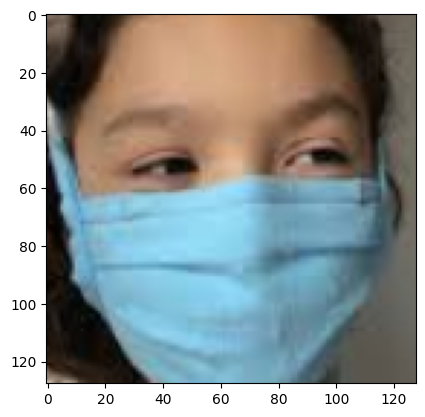

In [18]:
import os

# Construct the correct image path using the kagglehub variable
img_file_path = os.path.join(ashishjangra27_face_mask_12k_images_dataset_path, 'Face Mask Dataset', 'Test', 'WithMask', '1565.png')

sample_mask_img = cv2.imread(img_file_path)

if sample_mask_img is None:
    print(f"Error: Could not load image from {img_file_path}. Please check the path and if the file exists.")
else:
    sample_mask_img = cv2.resize(sample_mask_img,(128,128))
    plt.imshow(cv2.cvtColor(sample_mask_img, cv2.COLOR_BGR2RGB)) # Convert to RGB for matplotlib display
    sample_mask_img = np.reshape(sample_mask_img,[1,128,128,3])
    sample_mask_img = sample_mask_img/255.0

In [19]:
model.predict(sample_mask_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[9.9997270e-01, 1.5546937e-05]], dtype=float32)

The model is able to classify if the person is wearing a mask or not.

### Save the model.

In [20]:
model.save('masknet.h5')

### Integrating with haar cascade

We now take crops of the faces detected in the image and use the model trained in the above section to determine whether the individual faces have a mask or not.

In [21]:
mask_label = {0:'MASK',1:'NO MASK'}
dist_label = {0:(0,255,0),1:(255,0,0)}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


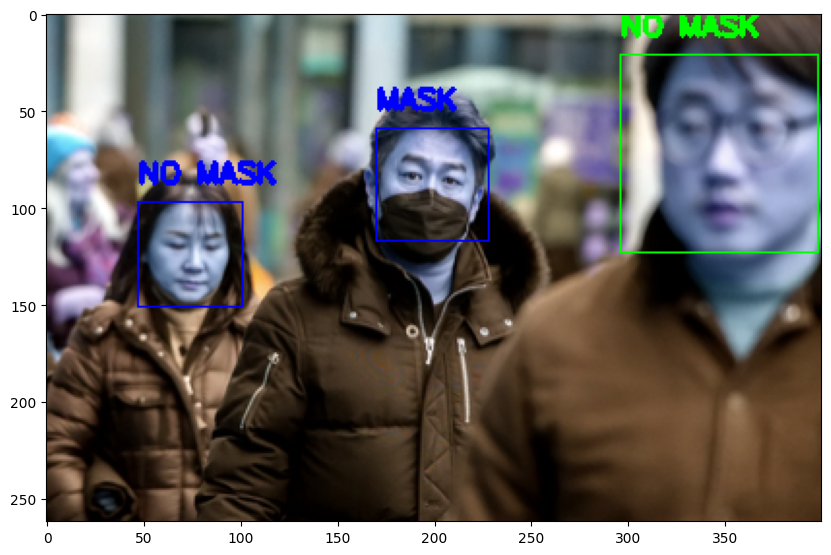

In [23]:
if len(faces)>=2:
    label = [0 for i in range(len(faces))]
    for i in range(len(faces)-1):
        for j in range(i+1, len(faces)):
            dist = distance.euclidean(faces[i][:2],faces[j][:2])
            if dist<MIN_DISTANCE:
                label[i] = 1
                label[j] = 1
    new_img = cv2.cvtColor(original_color_img, cv2.COLOR_RGB2BGR) #colored output image
    for i in range(len(faces)):
        (x,y,w,h) = faces[i]
        crop = new_img[y:y+h,x:x+w]
        crop = cv2.resize(crop,(128,128))
        crop = np.reshape(crop,[1,128,128,3])/255.0
        mask_result = model.predict(crop)
        cv2.putText(new_img,mask_label[mask_result.argmax()],(x, y-10),cv2.FONT_HERSHEY_SIMPLEX,0.5,dist_label[label[i]],2)
        cv2.rectangle(new_img,(x,y),(x+w,y+h),dist_label[label[i]],1)
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB)) # Convert back to RGB for matplotlib display

else:
    print("No. of faces detected is less than 2")

#### Red boxes shows violation of social distancing.